In [1]:
## automatically reload any modules read below that might have changed (e.g. plots)
%reload_ext autoreload
%autoreload 2

In [2]:
# importing plotting and locus tools: 
import NEOfaster as nf
import NEOMOD3 as nm3  

In [3]:
import re
import pandas as pd
import matplotlib.pyplot as plt
from urllib.request import urlopen
from io import StringIO
import numpy as np
import astropy.units as u
from astropy.time import Time
from numpy import sin, cos
from astropy.coordinates import EarthLocation, get_body_barycentric_posvel, solar_system_ephemeris 
from astropy.coordinates import SkyCoord, get_sun, GCRS, GeocentricTrueEcliptic
import pyarrow as pa
import adam_core.coordinates
from adam_core.time import Timestamp
from adam_core.coordinates import CartesianCoordinates, Origin
from adam_core.constants import KM_P_AU, S_P_DAY
from adam_core.orbits import Orbits
from adam_core.utils import get_perturber_state
from adam_core.coordinates.origin import OriginCodes
from scipy.interpolate import RegularGridInterpolator

#importing the neomod3.py file for the 4D array
import NEOMOD3 as nm3

In [4]:
df, array4D, H_center, a_center, e_center, i_center = nm3.getNEOMOD3orbits()

In [5]:
obstime_str="2025-09-23T00:00:00"
ra_deg, dec_deg, dra_deg_per_day, ddec_deg_per_day = 20.0, 50.0, 0.12, 0.22
# anti-Sun at Sep 23 = equinox so RA = 0, Dec = 0
ra0_deg, dec0_deg = 0.0, 0.0


In [6]:

l_hat, v_hat = nf.compute_unit_vectors(ra_deg, dec_deg, dra_deg_per_day, ddec_deg_per_day)
obstime, rE, vE, r_obs = nf.get_earth_and_observer(obstime_str) 
neo_score, a, e, i = nf.compute_neomod3_weight(0.20, 3.0, l_hat, v_hat, obstime, rE, vE, r_obs, array4D, H_center, a_center, e_center, i_center)




print("neo_score:", neo_score)
print("a:", a)
print("e:", e)
print("i:", i)

neo_score: 0.2167
a: 1.6198874073095557
e: 0.3155680774315522
i: 28.45097596997941


In [10]:
def comp_sum():
    
    N_rate = 31 #2 mins 30 sec, for 31 = 4 mins 20 sec so around 50 mins for 101
    dra_vals  = np.linspace(-0.6, 0.6, N_rate)
    ddec_vals = np.linspace(-0.6, 0.6, N_rate)
    
    
    vlam_edges = np.linspace(-0.6, 0.6, 121)
    vbet_edges = np.linspace(-0.6, 0.6, 121)
    
    
    H = np.zeros((len(vbet_edges)-1, len(vlam_edges)-1), dtype=float)
    
    for dra in dra_vals:
        for ddec in ddec_vals:
            vlam, vbet = nf.radec_rates_to_ecliptic_rates1(ra0_deg, dec0_deg, dra, ddec)
            w_int = nf.weight_marginalized_over_d_and_ddot(array4D=array4D, H_center=H_center, a_center=a_center, e_center=e_center, i_center=i_center,
                                                        ra_deg=ra0_deg, dec_deg=dec0_deg, dra_deg_per_day=dra, ddec_deg_per_day=ddec,
                                                        H0=19.0, i0=25.9, obstime_str=obstime_str)
            
            i = np.searchsorted(vlam_edges, vlam) - 1
            j = np.searchsorted(vbet_edges, vbet) - 1
            if 0 <= i < H.shape[1] and 0 <= j < H.shape[0]:
                H[j, i] += w_int
            #print(w_int, dra, ddec)
        #break
    extent = [vlam_edges[0], vlam_edges[-1], vbet_edges[0], vbet_edges[-1]]
    return H, extent

H, extent= comp_sum()


/tmp/ipykernel_219405/70712927.py:5: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  my_viridis = cm.get_cmap("viridis", 1024).with_extremes(under="white")


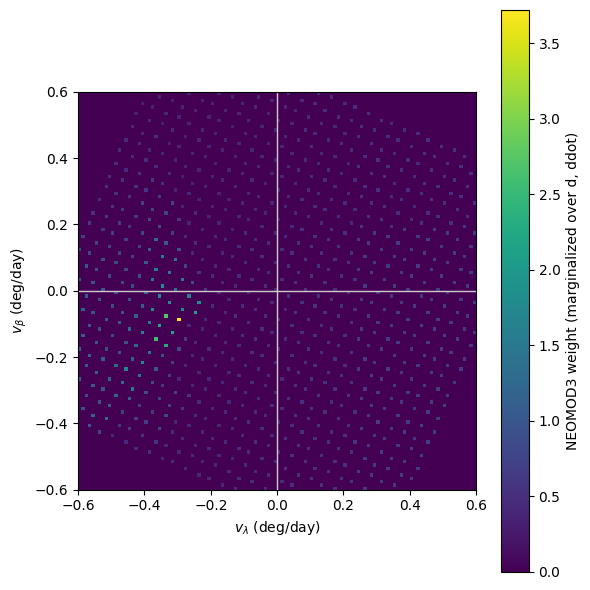

Min: 0.0
Max: 3.7211501389999992
Mean: 0.03361802705630377
Std: 0.1563254027708832
Variance: 0.024437631551478853


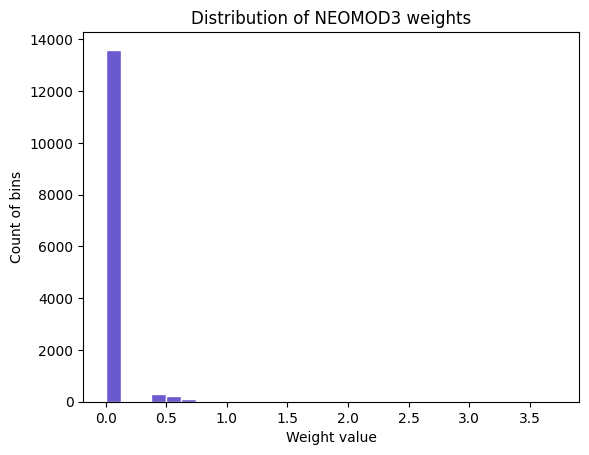

Nonzero mean: 0.6013659498270488
Nonzero std: 0.3093880112779012


In [11]:
from matplotlib import cm
plt.figure(figsize=(6.0, 6.0))
#extent = [vlam_edges[0], vlam_edges[-1], vbet_edges[0], vbet_edges[-1]]
 
my_viridis = cm.get_cmap("viridis", 1024).with_extremes(under="white")
im = plt.imshow(H, origin="lower", extent=extent, cmap=my_viridis, aspect="equal")


plt.colorbar(label="NEOMOD3 weight (marginalized over d, ddot)")

plt.axhline(0, color="0.8", lw=1)
plt.axvline(0, color="0.8", lw=1)
plt.xlabel(r"$v_\lambda$ (deg/day)")
plt.ylabel(r"$v_\beta$ (deg/day)")
#plt.title("v_lambda–v_beta distribution (integrated over d [0.05,5] AU, ddot [−60,60] km/s)\n"
#          f"{obstime_str}")
plt.tight_layout()
plt.show()
print("Min:", np.nanmin(H))
print("Max:", np.nanmax(H))
print("Mean:", np.nanmean(H))
print("Std:", np.nanstd(H))
print("Variance:", np.nanvar(H))
plt.figure()
plt.hist(H.flatten(), bins=30, color='slateblue', edgecolor='white')
plt.xlabel("Weight value")
plt.ylabel("Count of bins")
plt.title("Distribution of NEOMOD3 weights")
plt.show()
nonzero = H[H > 0]
print("Nonzero mean:", np.mean(nonzero))
print("Nonzero std:", np.std(nonzero))
